## Drum Samples Data Visualiation

Below is a csv populated with the training set we have collected. Labels have been extracted via parsing the filename of the audio samples for categorical key words. Some feature sets do not have labels. 

In [27]:
import pandas as pd
import numpy as np
import seaborn as sns

spectral_data = pd.read_csv('sample_data.csv')

# hacky way to have label as first column cause im lazy

cols = ['label'] + [col for col in spectral_data.columns if col != 'label']
spectral_data = spectral_data[cols]


spectral_data

,label,bandwidth_kurtosis,bandwidth_max,bandwidth_mean,bandwidth_median,bandwidth_min,bandwidth_skew,bandwidth_std,centroid_kurtosis,centroid_max,...,rolloff_min,rolloff_skew,rolloff_std,zcr_kurtosis,zcr_max,zcr_mean,zcr_median,zcr_min,zcr_skew,zcr_std
0,808,1.698427,2403.595938,863.131279,699.947227,451.368816,1.693562,548.975345,9.554585,2836.396812,...,164.0625,2.534027,1288.086857,-1.300260,0.056152,0.029178,0.035645,0.012207,-0.036817,0.013643
1,808,26.474176,1893.644756,233.262143,180.621267,146.388594,5.190635,262.440464,44.369234,1133.309601,...,31.2500,7.328726,316.774809,3.907998,0.009277,0.004472,0.004395,0.001465,1.578395,0.001302
2,808,16.410115,2503.022018,390.564968,278.040203,141.326365,3.717253,381.477105,41.833772,3397.250299,...,54.6875,6.172848,859.203498,25.825264,0.223145,0.015039,0.005859,0.005371,5.149168,0.035470
3,808,3.511289,507.737599,382.490377,387.856748,132.168467,-1.658850,74.109604,1.652341,198.536720,...,54.6875,-0.694766,55.100986,9.186672,0.007324,0.005532,0.005371,0.004395,2.010687,0.000358
4,808,10.825649,2221.657797,813.077195,716.993793,649.987823,3.017825,246.279761,55.983315,1956.614259,...,7.8125,7.931070,492.593595,1.892951,0.019531,0.005937,0.007324,0.000000,0.501241,0.003710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19652,kick,2.032114,2085.906558,729.268338,475.559958,347.835893,1.856573,540.637313,2.375602,1699.294018,...,78.1250,2.158795,1425.636430,-1.728058,0.068359,0.030579,0.010742,0.005859,0.503482,0.028955
19653,kick,0.813470,2585.797363,402.152019,0.000000,0.000000,1.585861,792.942602,7.187291,3330.799550,...,0.0000,2.591797,1598.247255,5.570439,0.153320,0.016113,0.000000,0.000000,2.606426,0.039157
19654,kick,6.998810,2566.181633,371.847691,157.926538,0.000000,2.806876,589.188796,12.131366,3275.793224,...,0.0000,3.783788,1426.711487,8.295282,0.155273,0.017522,0.007324,0.000000,3.098563,0.035049
19655,kick,-0.605197,2399.608068,865.347053,612.437067,129.345319,0.837034,705.901975,2.749598,2473.156777,...,54.6875,1.657204,1661.336190,4.986770,0.045898,0.010216,0.006348,0.003906,2.564912,0.010947


In [28]:
# displaying amount of each label in dataset
# ideally we want a roughly equal amount of each label

label_counts = spectral_data['label'].value_counts()
label_counts

label
kick      7795
snare     4410
clap      3304
cymbal    1952
hi_hat    1152
808       1044
Name: count, dtype: int64

## Data Sanitization

Dropping feature sets that were not able to be labelled.

In [29]:
spectral_data = spectral_data[spectral_data['label'] != 'unknown']
spectral_data

,label,bandwidth_kurtosis,bandwidth_max,bandwidth_mean,bandwidth_median,bandwidth_min,bandwidth_skew,bandwidth_std,centroid_kurtosis,centroid_max,...,rolloff_min,rolloff_skew,rolloff_std,zcr_kurtosis,zcr_max,zcr_mean,zcr_median,zcr_min,zcr_skew,zcr_std
0,808,1.698427,2403.595938,863.131279,699.947227,451.368816,1.693562,548.975345,9.554585,2836.396812,...,164.0625,2.534027,1288.086857,-1.300260,0.056152,0.029178,0.035645,0.012207,-0.036817,0.013643
1,808,26.474176,1893.644756,233.262143,180.621267,146.388594,5.190635,262.440464,44.369234,1133.309601,...,31.2500,7.328726,316.774809,3.907998,0.009277,0.004472,0.004395,0.001465,1.578395,0.001302
2,808,16.410115,2503.022018,390.564968,278.040203,141.326365,3.717253,381.477105,41.833772,3397.250299,...,54.6875,6.172848,859.203498,25.825264,0.223145,0.015039,0.005859,0.005371,5.149168,0.035470
3,808,3.511289,507.737599,382.490377,387.856748,132.168467,-1.658850,74.109604,1.652341,198.536720,...,54.6875,-0.694766,55.100986,9.186672,0.007324,0.005532,0.005371,0.004395,2.010687,0.000358
4,808,10.825649,2221.657797,813.077195,716.993793,649.987823,3.017825,246.279761,55.983315,1956.614259,...,7.8125,7.931070,492.593595,1.892951,0.019531,0.005937,0.007324,0.000000,0.501241,0.003710
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19652,kick,2.032114,2085.906558,729.268338,475.559958,347.835893,1.856573,540.637313,2.375602,1699.294018,...,78.1250,2.158795,1425.636430,-1.728058,0.068359,0.030579,0.010742,0.005859,0.503482,0.028955
19653,kick,0.813470,2585.797363,402.152019,0.000000,0.000000,1.585861,792.942602,7.187291,3330.799550,...,0.0000,2.591797,1598.247255,5.570439,0.153320,0.016113,0.000000,0.000000,2.606426,0.039157
19654,kick,6.998810,2566.181633,371.847691,157.926538,0.000000,2.806876,589.188796,12.131366,3275.793224,...,0.0000,3.783788,1426.711487,8.295282,0.155273,0.017522,0.007324,0.000000,3.098563,0.035049
19655,kick,-0.605197,2399.608068,865.347053,612.437067,129.345319,0.837034,705.901975,2.749598,2473.156777,...,54.6875,1.657204,1661.336190,4.986770,0.045898,0.010216,0.006348,0.003906,2.564912,0.010947


In [30]:
label_counts = spectral_data['label'].value_counts()
label_counts

label
kick      7795
snare     4410
clap      3304
cymbal    1952
hi_hat    1152
808       1044
Name: count, dtype: int64

## Finding Correlations

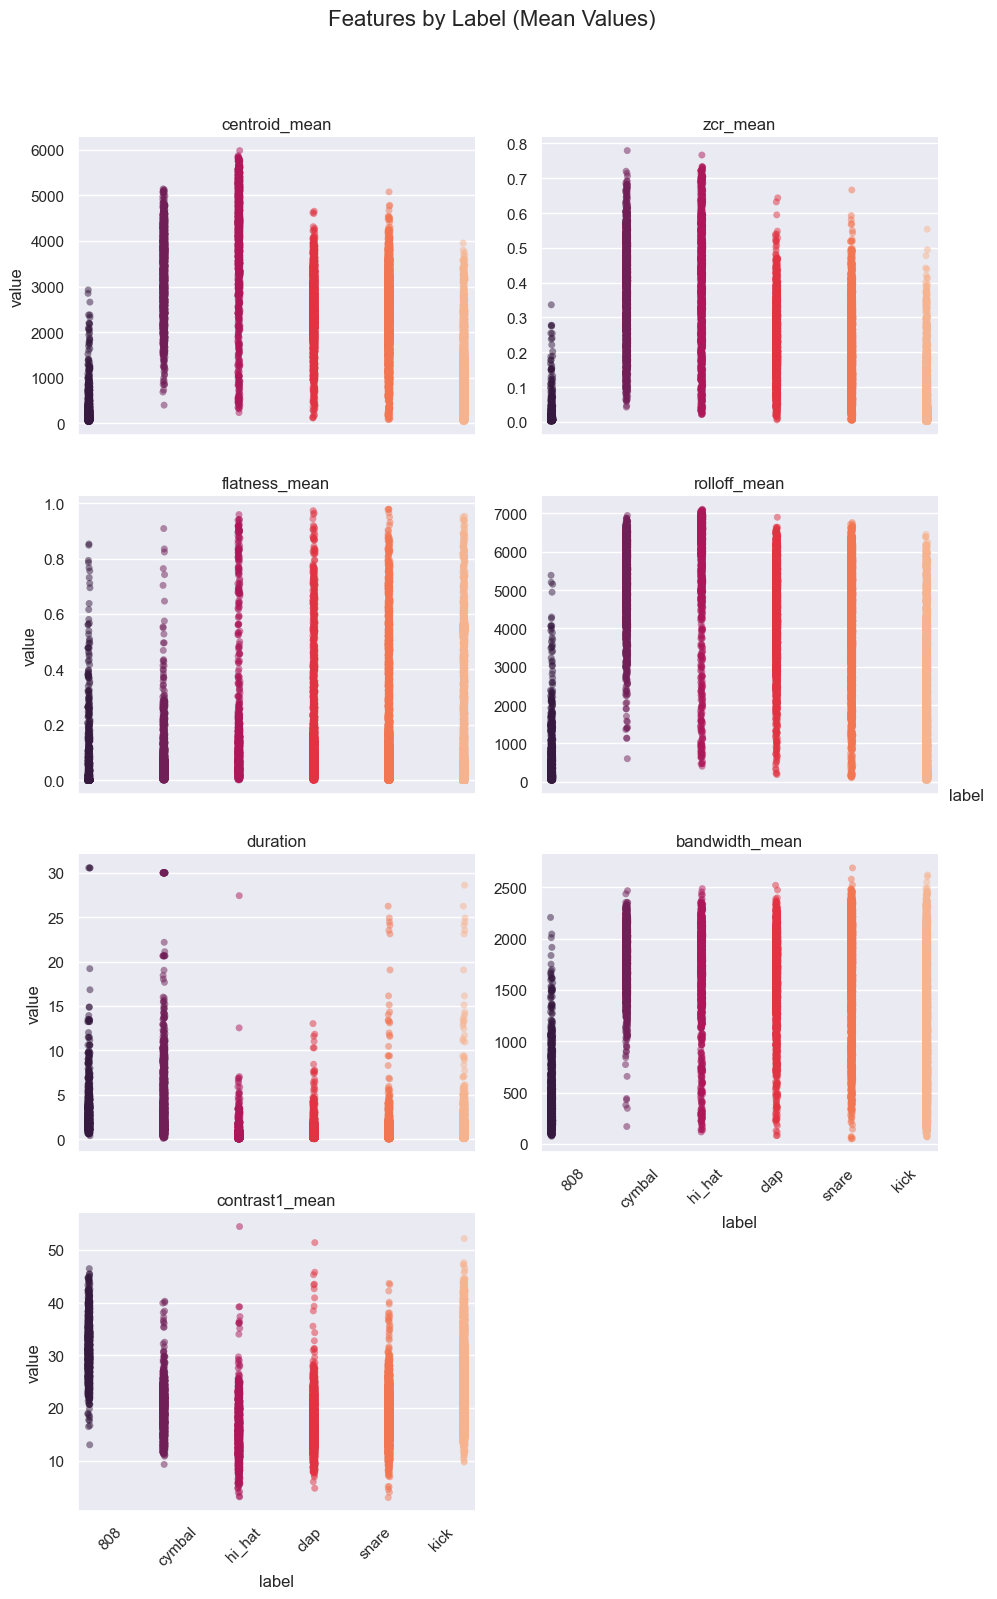

In [31]:
import matplotlib.pyplot as plt

# Assuming 'sample_data.csv' is the output from your new extraction script
spectral_data = pd.read_csv("sample_data.csv")

sns.set_palette("rocket")
sns.set_theme(context="notebook", style="darkgrid")

spectral_data = spectral_data.reset_index(drop=True)
spectral_data['sample_id'] = spectral_data.index

features = [
    'centroid_mean', 
    'zcr_mean', 
    'flatness_mean', 
    'rolloff_mean', 
    'duration', 
    'bandwidth_mean', 
    'contrast1_mean'
]

long_df = spectral_data.melt(
    id_vars=["sample_id", "label"],
    value_vars=features,
    var_name="feature",
    value_name="value"
)

g = sns.FacetGrid(
    data=long_df,
    col="feature",
    col_wrap=2,
    sharey=False,
    height=4,
    aspect=1.2
)

g.map_dataframe(
    sns.stripplot,
    x="label",
    y="value",
    hue="label",
    jitter=True,
    alpha=0.5,
    dodge=True,
    palette="rocket"
)

for ax in g.axes.ravel():
    ax.tick_params(axis='x', rotation=45)

g.add_legend(title="label")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.9)
g.figure.suptitle("Features by Label (Mean Values)", fontsize=16)
plt.show()

### MFCC Coefficient Analysis

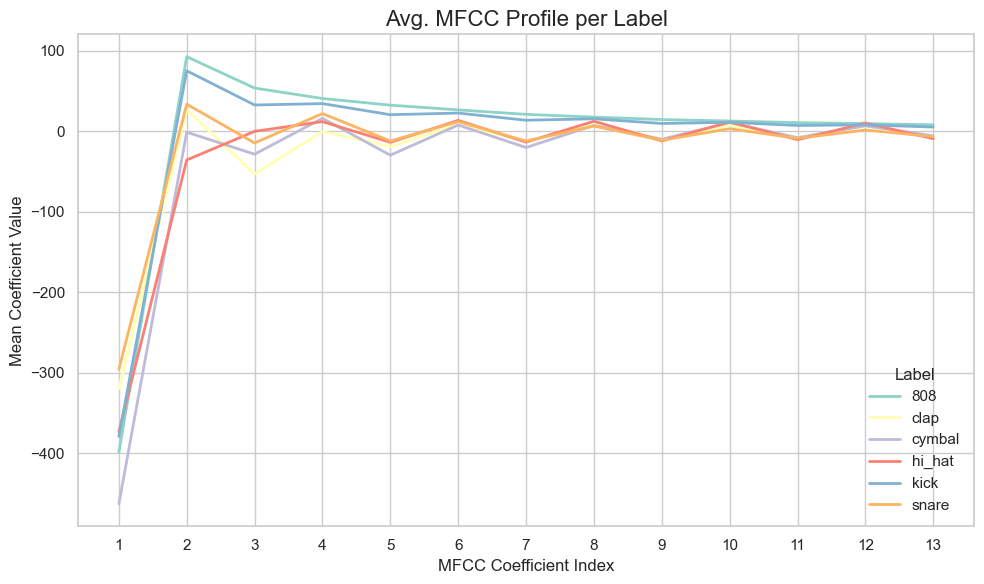

In [32]:
sns.set_theme(style="whitegrid")
palette = sns.color_palette("Set3", n_colors=spectral_data["label"].nunique())

mfcc_cols = [f"mfcc{i+1}_mean" for i in range(13)]

label_means = spectral_data.groupby("label")[mfcc_cols].mean()

plt.figure(figsize=(10, 6))
for color, (label, row) in zip(palette, label_means.iterrows()):
    plt.plot(range(1, 14), row.values, label=label, color=color, linewidth=2)

plt.title("Avg. MFCC Profile per Label", fontsize=16)
plt.xlabel("MFCC Coefficient Index", fontsize=12)
plt.ylabel("Mean Coefficient Value", fontsize=12)
plt.xticks(ticks=range(1, 14))
plt.legend(title="Label", frameon=False)
plt.tight_layout()
plt.show()

## Average Spectrogram

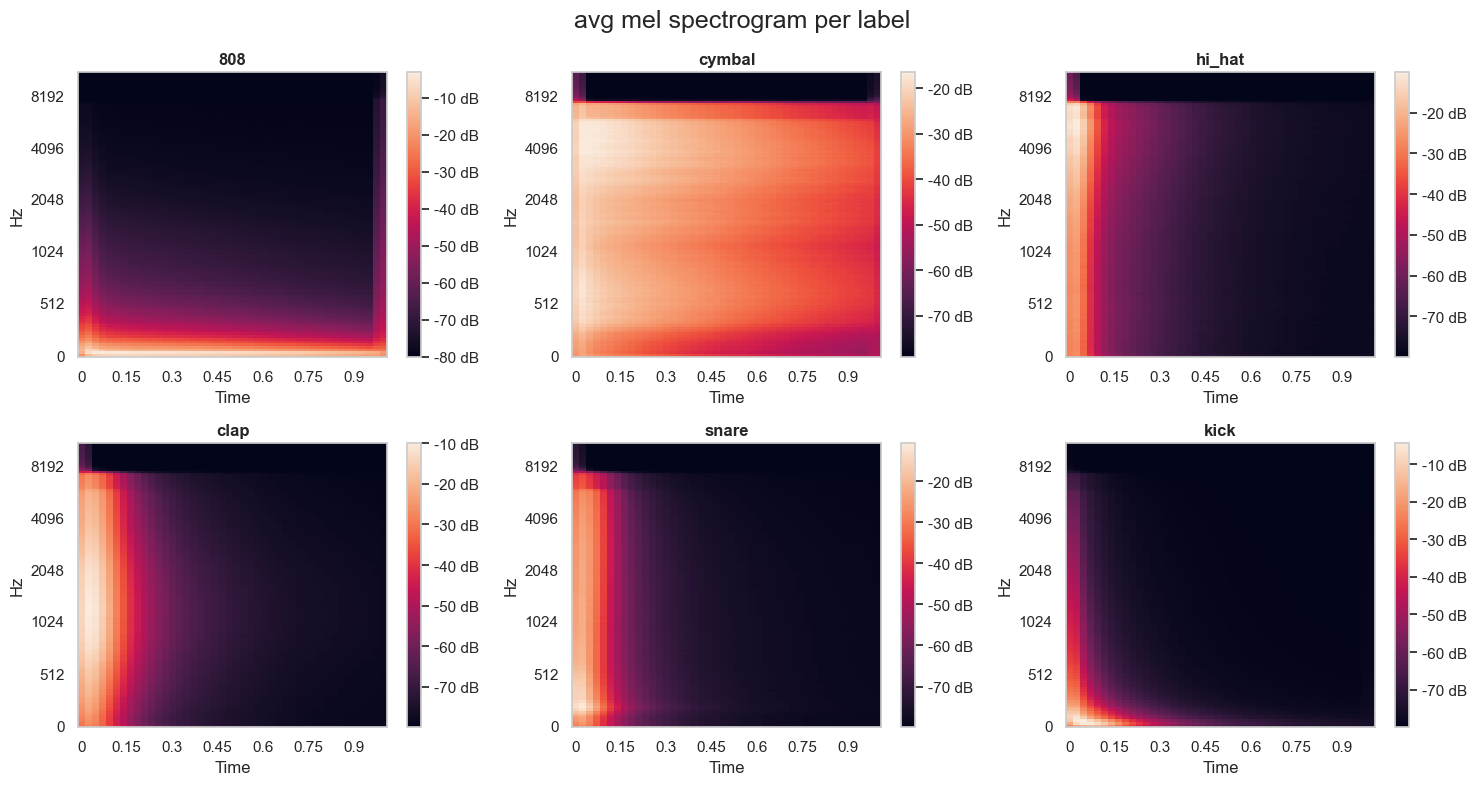

In [33]:
import librosa
import librosa.display

# spectrogram params
n_mels     = 128
hop_length = 512
sr         = 22_050
duration   = 1.0      
n_fft      = 2048
fixed_len  = int(sr * duration)

specs_by_label = {}

for _, row in spectral_data.iterrows():
    y, _ = librosa.load(row["file"], sr=sr, duration=duration, mono=True)
    y = librosa.util.fix_length(y, size=fixed_len)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)

    label = row["label"]
    specs_by_label.setdefault(label, []).append(log_mel)

ncols  = 3
labels = list(specs_by_label.keys())
nrows  = (len(labels) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(15, 4 * nrows), sharex=False, sharey=False
)
axes = axes.flatten()

for i, label in enumerate(labels):
    avg_spec = np.mean(np.stack(specs_by_label[label]), axis=0)

    img = librosa.display.specshow(
        avg_spec,
        sr=sr,
        hop_length=hop_length,
        x_axis="time",
        y_axis="mel",
        cmap="rocket",
        ax=axes[i],
    )
    axes[i].set_title(label, fontweight="bold")

    fig.colorbar(img, ax=axes[i], format="%+2.f dB")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("avg mel spectrogram per label", fontsize=18)
fig.tight_layout()
plt.show()


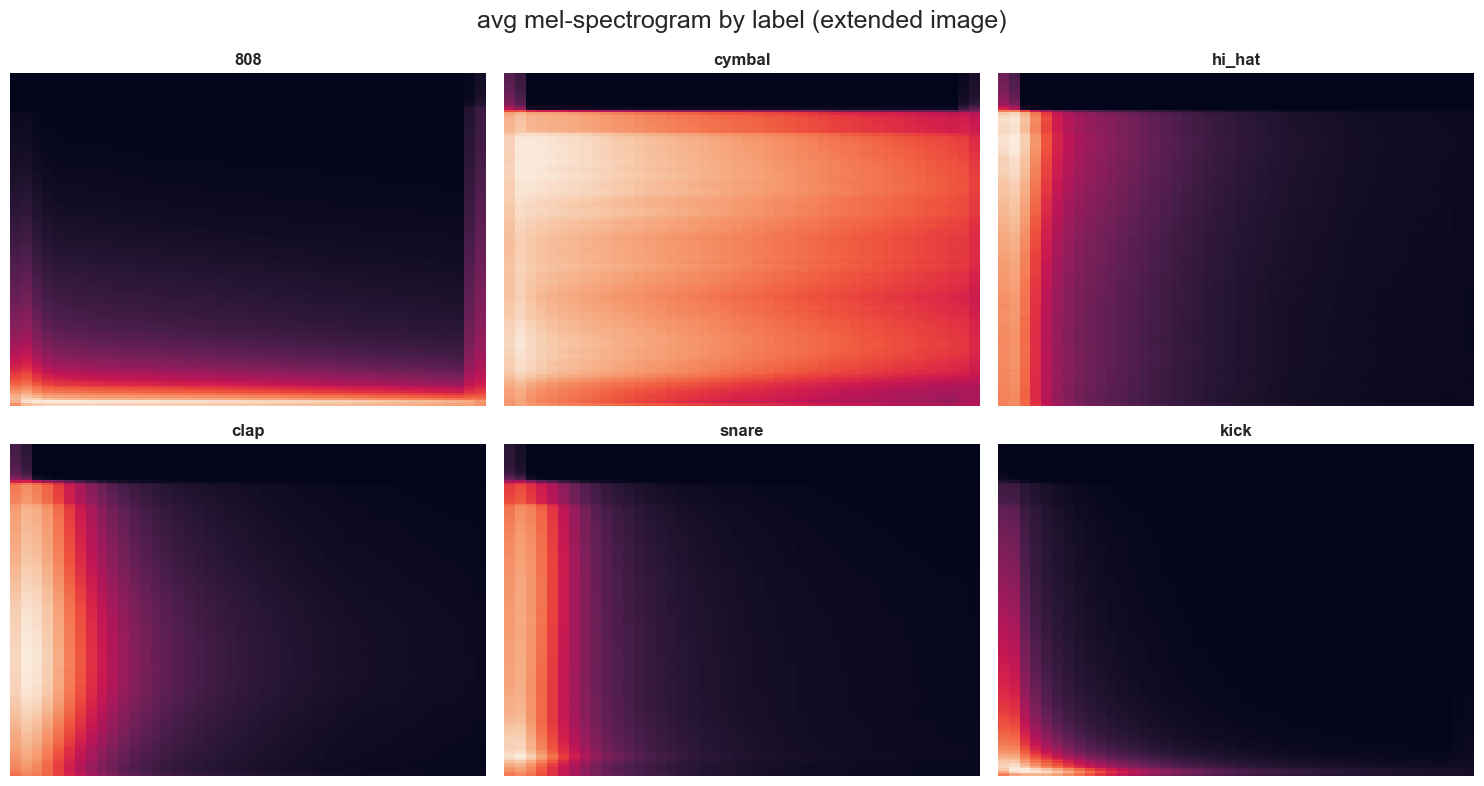

In [34]:

n_mels     = 128
hop_length = 512
sr         = 22_050
duration   = 1.0          
n_fft      = 2048
fixed_len  = int(sr * duration)

specs_by_label = {}

for _, row in spectral_data.iterrows():
    y, _ = librosa.load(row["file"], sr=sr, duration=duration, mono=True)
    y = librosa.util.fix_length(y, size=fixed_len)

    mel = librosa.feature.melspectrogram(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_mels=n_mels
    )
    log_mel = librosa.power_to_db(mel, ref=np.max)

    label = row["label"]
    specs_by_label.setdefault(label, []).append(log_mel)

ncols  = 3
labels = list(specs_by_label.keys())
nrows  = (len(labels) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows),
    sharex=False,
    sharey=False,
)
axes = axes.flatten()

for i, label in enumerate(labels):
    avg_spec = np.mean(np.stack(specs_by_label[label]), axis=0)

    librosa.display.specshow(
        avg_spec,
        sr=sr,
        hop_length=hop_length,
        cmap="rocket",
        ax=axes[i],
    )

    axes[i].set_title(label, fontweight="bold")
    axes[i].set_axis_off()            

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("avg mel-spectrogram by label (extended image)", fontsize=18)
fig.tight_layout()
plt.show()

## Average Chromagram

(for fun)

/Users/Malcosalcedo/sound-sample-organizer-1/venv/lib/python3.9/site-packages/librosa/core/pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(


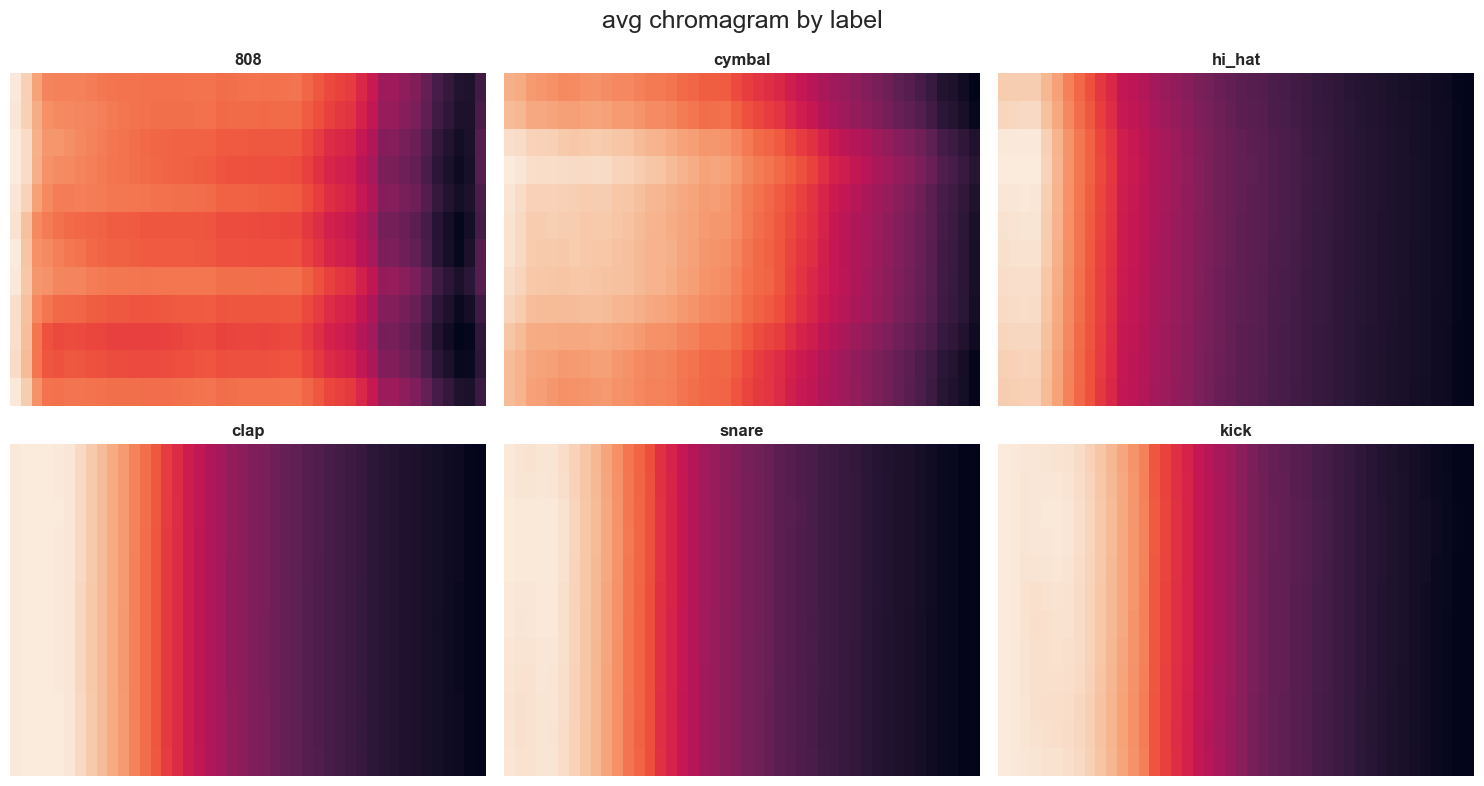

In [35]:
n_chroma   = 12           
hop_length = 512
sr         = 22_050
duration   = 1.0           
n_fft      = 2048          
fixed_len  = int(sr * duration)

chromas_by_label = {}

for _, row in spectral_data.iterrows():
    y, _ = librosa.load(row["file"], sr=sr, duration=duration, mono=True)
    y = librosa.util.fix_length(y, size=fixed_len)

    chroma = librosa.feature.chroma_stft(
        y=y, sr=sr, n_fft=n_fft, hop_length=hop_length, n_chroma=n_chroma
    )
    chroma_db = librosa.power_to_db(chroma, ref=np.max)   

    label = row["label"]
    chromas_by_label.setdefault(label, []).append(chroma_db)

ncols  = 3
labels = list(chromas_by_label.keys())
nrows  = (len(labels) + ncols - 1) // ncols

fig, axes = plt.subplots(
    nrows=nrows,
    ncols=ncols,
    figsize=(15, 4 * nrows),
    sharex=False,
    sharey=False,
)
axes = axes.flatten()

for i, label in enumerate(labels):
    avg_chroma = np.mean(np.stack(chromas_by_label[label]), axis=0)

    librosa.display.specshow(
        avg_chroma,
        sr=sr,
        hop_length=hop_length,
        cmap="rocket",
        ax=axes[i],
    )

    axes[i].set_title(label, fontweight="bold")
    axes[i].set_axis_off()            

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("avg chromagram by label", fontsize=18)
fig.tight_layout()
plt.show()

## Creating a preliminary model

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier
from joblib import dump

# Load data extracted from the script above
spectral_data = pd.read_csv("sample_data.csv")

# Generate the new, expanded feature list
BASE_FEATURES = ["zcr", "centroid", "rolloff", "flatness", "bandwidth"]
STATS = ["mean", "std", "skew", "kurtosis", "median", "min", "max"]
FEATURE_COLUMNS = [f"{feat}_{stat}" for feat in BASE_FEATURES for stat in STATS]
FEATURE_COLUMNS += [f"contrast{i+1}_{stat}" for i in range(7) for stat in STATS]
FEATURE_COLUMNS += [f"mfcc{i+1}_{stat}" for i in range(13) for stat in STATS]


feature_set = spectral_data[FEATURE_COLUMNS]
unprocessed_label_set = spectral_data['label']

label_encoder = LabelEncoder()
label_set = label_encoder.fit_transform(unprocessed_label_set)

feature_train, feature_test, label_train, label_test = train_test_split(
    feature_set,
    label_set,
    test_size=0.20,
    random_state=42,
    stratify=label_set
)

# XGBoost model pipeline
xgboost_model = Pipeline([
    ('scale', StandardScaler()),
    ('xgb', XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=7,
        eval_metric='mlogloss',
        random_state=42
    ))
])

print("Training XGBoost model...")
xgboost_model.fit(feature_train, label_train)

print("5-fold CV accuracy:",
      cross_val_score(xgboost_model, feature_set, label_set, cv=5, scoring='accuracy').mean().round(3))

predictions = xgboost_model.predict(feature_test)
print("\nClassification report\n", classification_report(
    label_test, predictions, target_names=label_encoder.classes_))

print("\nConfusion matrix\n", confusion_matrix(label_test, predictions))

bundle = {
    "model": xgboost_model,
    "label_encoder": label_encoder,
    "columns": FEATURE_COLUMNS
}
dump(bundle, "xgboost_bundle.joblib")

Training XGBoost model...
5-fold CV accuracy: 0.918

Classification report
               precision    recall  f1-score   support

         808       0.88      0.90      0.89       209
        clap       0.85      0.88      0.87       661
      cymbal       0.95      0.94      0.95       391
      hi_hat       0.88      0.88      0.88       230
        kick       0.97      0.97      0.97      1559
       snare       0.89      0.87      0.88       882

    accuracy                           0.92      3932
   macro avg       0.90      0.91      0.91      3932
weighted avg       0.92      0.92      0.92      3932


Confusion matrix
 [[ 189    0    0    0   19    1]
 [   0  583    1    7    1   69]
 [   0    8  368   14    0    1]
 [   0    6   13  203    0    8]
 [  27    2    0    0 1515   15]
 [   0   86    4    7   19  766]]


['xgboost_bundle.joblib']